In [1]:
!pip install torch torchvision

In [1]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from PIL import Image
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from scipy.stats import entropy

# Thêm thư mục gốc vào path để import src
sys.path.append(os.path.abspath(os.path.join('..')))
from src.utils import load_cifar10_longtail
from src.model import hierarchical_kmeans_resampling
from src.metrics import calculate_acc, calculate_nmi # Đảm bảo bạn đã có hàm này trong metrics.py

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hệ thống sẵn sàng. Thiết bị sử dụng: {device}")

d:\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
d:\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Hệ thống sẵn sàng. Thiết bị sử dụng: cpu


Lớp 0: giữ lại 5000 ảnh
Lớp 1: giữ lại 3584 ảnh
Lớp 2: giữ lại 2569 ảnh
Lớp 3: giữ lại 1842 ảnh
Lớp 4: giữ lại 1320 ảnh
Lớp 5: giữ lại 946 ảnh
Lớp 6: giữ lại 678 ảnh
Lớp 7: giữ lại 486 ảnh
Lớp 8: giữ lại 348 ảnh
Lớp 9: giữ lại 250 ảnh


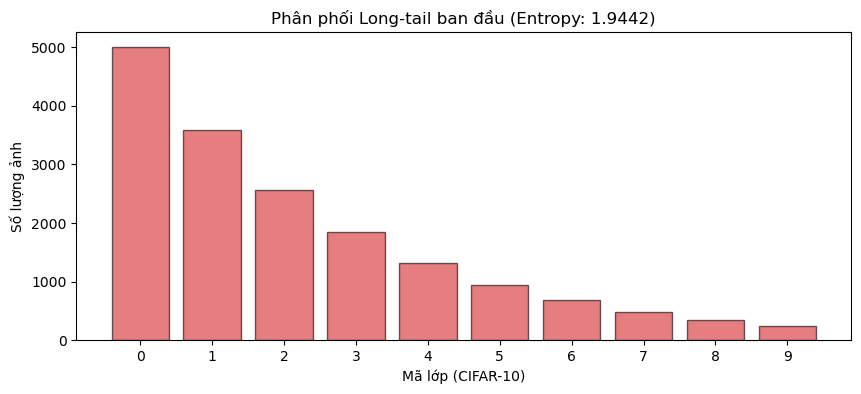

In [2]:
# Cấu hình: Lớp 0 có 5000 ảnh, Lớp 9 chỉ có 50 ảnh (Tỷ lệ 100 lần)
PATH_CIFAR = '../data/cifar-10-batches-py'
X_images, Y_labels = load_cifar10_longtail(PATH_CIFAR, imbalance_ratio=0.05)

# Trực quan hóa độ lệch ban đầu
classes, counts = np.unique(Y_labels, return_counts=True)
plt.figure(figsize=(10, 4))
plt.bar(classes, counts, color='tab:red', alpha=0.6, edgecolor='black')
plt.title(f"Phân phối Long-tail ban đầu (Entropy: {entropy(counts/len(Y_labels)):.4f})")
plt.xlabel("Mã lớp (CIFAR-10)")
plt.ylabel("Số lượng ảnh")
plt.xticks(range(10))
plt.show()

In [ ]:
# 1. Tải mô hình DINOv2 (Bản ViT-S nhỏ gọn)
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').to(device)
dinov2.eval()

# 2. Định nghĩa Transform chuẩn
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class SimpleDataset(Dataset):
    def __init__(self, imgs, transform):
        self.imgs = imgs
        self.transform = transform
    def __len__(self): return len(self.imgs)
    def __getitem__(self, idx):
        return self.transform(Image.fromarray(self.imgs[idx]))

# 3. Thực hiện trích xuất theo Batch để tối ưu tốc độ
loader = DataLoader(SimpleDataset(X_images, transform), batch_size=128, shuffle=False)
features = []

print("Đang trích xuất đặc trưng bằng DINOv2...")
with torch.no_grad():
    for batch in tqdm(loader):
        feat = dinov2(batch.to(device))
        features.append(feat.cpu().numpy())

X_feats = np.vstack(features)
# Chuẩn hóa L2 cho đặc trưng (Quan trọng cho K-means)
X_feats_norm = normalize(X_feats) 
print(f"Hoàn thành! Kích thước Feature Map: {X_feats_norm.shape}")

Using cache found in C:\Users\QUANG THINH/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\QUANG THINH/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\QUANG THINH/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\QUANG THINH/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Đang trích xuất đặc trưng bằng DINOv2...


 50%|█████     | 67/133 [07:45<07:25,  6.75s/it]

In [ ]:
# Cấu hình k_list theo tỷ lệ giảm dần của bài báo
# Tầng 1: 1000 cụm (xẻ nhỏ vùng đậm đặc), Tầng cuối: 100 cụm (Concepts)
k_list = [1500, 600, 300]
r_t_list = [5, 2, 1] 

print("Đang chạy Hierarchical K-means Resampling...")
centroids_final = hierarchical_kmeans_resampling(
    X_feats_norm, k_list, T=3, m=10, r_t_list=r_t_list, num_init=3
)

# Gán nhãn cụm cho toàn bộ ảnh
km_final = KMeans(n_clusters=300, init=centroids_final, n_init=1).fit(X_feats_norm)
cluster_labels = km_final.labels_

Đang chạy Hierarchical K-means Resampling...


NameError: name 'X_feats_norm' is not defined

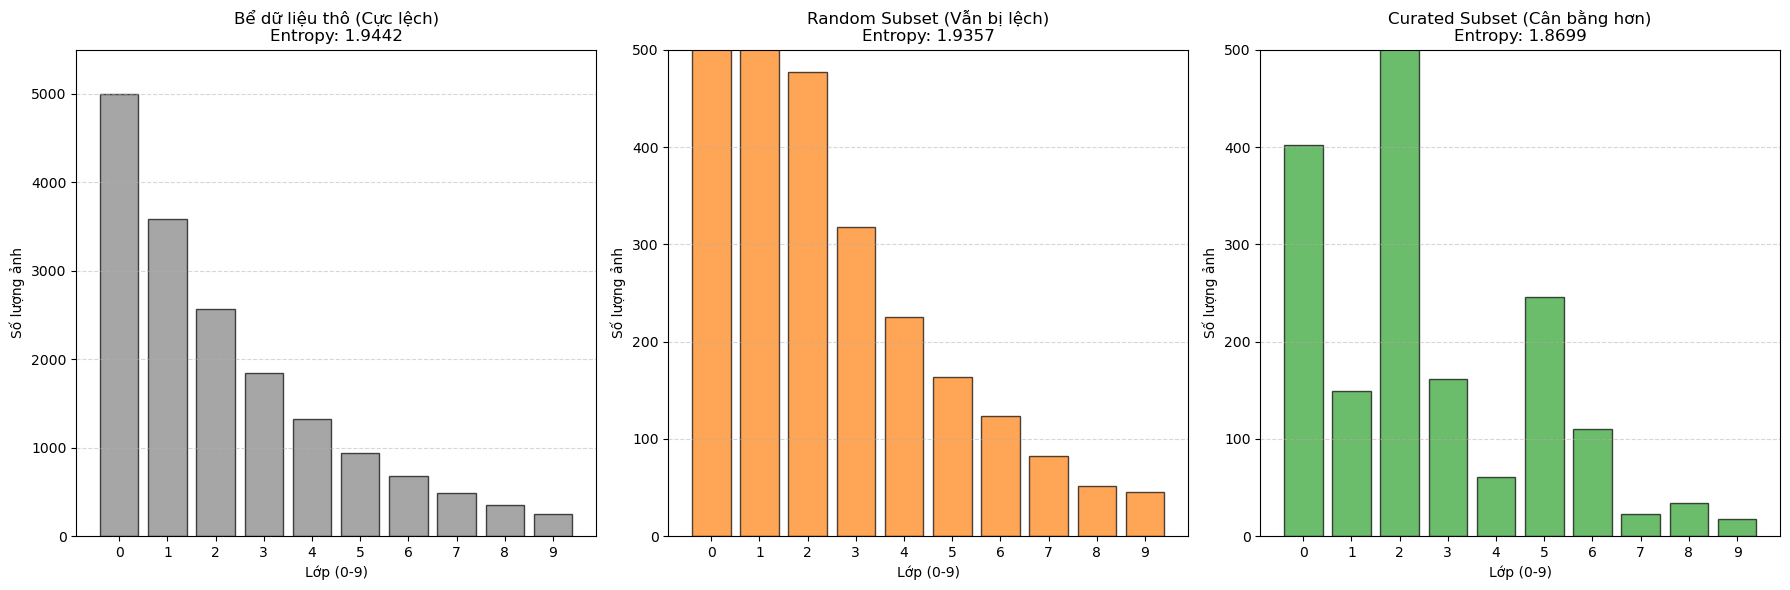

Lý tưởng (Cân bằng tuyệt đối): 2.3026


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

# Cố định Seed để đảm bảo tính tái hiện (Yêu cầu 3.2.2)
SEED = 42
np.random.seed(SEED)

# 1. Lấy mẫu Ngẫu nhiên (Baseline) - Đã thêm random_state
idx_random = np.random.choice(len(Y_labels), 3000, replace=False)
Y_random_subset = Y_labels[idx_random]

# 2. Lấy mẫu Curated (Mỗi cụm lấy 10 ảnh gần tâm nhất) - Giữ nguyên logic cũ
idx_curated = []
for i in range(300):
    cluster_idx = np.where(cluster_labels == i)[0]
    if len(cluster_idx) == 0: continue
    dists = np.linalg.norm(X_feats_norm[cluster_idx] - centroids_final[i], axis=1)
    top_10 = cluster_idx[np.argsort(dists)[:10]]
    idx_curated.extend(top_10)
Y_curated_subset = Y_labels[idx_curated]

# 3. Tính toán Entropy
entropy_raw = entropy(np.unique(Y_labels, return_counts=True)[1] / len(Y_labels))
entropy_rand = entropy(np.unique(Y_random_subset, return_counts=True)[1] / len(Y_random_subset))
entropy_ours = entropy(np.unique(Y_curated_subset, return_counts=True)[1] / len(Y_curated_subset))

# 4. VẼ BIỂU ĐỒ SO SÁNH (ĐÃ FIX SCALE)
def plot_hist_fixed(y, title, color, ent, y_limit):
    cls, cnt = np.unique(y, return_counts=True)
    full_cnt = np.zeros(10); full_cnt[cls] = cnt
    plt.bar(range(10), full_cnt, color=color, alpha=0.7, edgecolor='black')
    plt.title(f"{title}\nEntropy: {ent:.4f}")
    plt.xlabel("Lớp (0-9)")
    plt.ylabel("Số lượng ảnh")
    plt.ylim(0, y_limit) # Fix lỗi cắt ngọn
    plt.xticks(range(10))
    plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.figure(figsize=(18, 6))

# Subplot 1: Bể dữ liệu thô (Scale 5000 vì lớp 0 có 5000 ảnh)
plt.subplot(1, 3, 1)
plot_hist_fixed(Y_labels, "Bể dữ liệu thô (Cực lệch)", "gray", entropy_raw, 5500)

# Subplot 2: Random (Scale 500 để thấy độ dốc của 1000 mẫu)
plt.subplot(1, 3, 2)
plot_hist_fixed(Y_random_subset, "Random Subset (Vẫn bị lệch)", "tab:orange", entropy_rand, 1000)

# Subplot 3: HK-means (Scale 500 để so sánh trực tiếp với Random)
plt.subplot(1, 3, 3)
plot_hist_fixed(Y_curated_subset, "Curated Subset (Cân bằng hơn)", "tab:green", entropy_ours, 1000)

plt.tight_layout()
plt.show()

print(f"Lý tưởng (Cân bằng tuyệt đối): {np.log(10):.4f}")

In [ ]:
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from PIL import Image

# Định nghĩa lại Class Dataset để DataLoader có thể đọc được mảng ảnh
class CifarDataset(Dataset):
    def __init__(self, images, transform=None):
        self.images = images
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        # Chuyển từ numpy sang PIL Image để transform (Resize, v.v.)
        img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)
        return img

def extract_features_fast(X_images, batch_size=64):
    """
    Hàm trích xuất đặc trưng bằng DINOv2 theo từng Batch để tối ưu tốc độ.
    """
    dataset = CifarDataset(X_images, transform=transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    feats = []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Đang trích xuất đặc trưng"):
            # 'model' và 'device' đã được định nghĩa ở các Cell setup phía trên
            batch = batch.to(device)
            feat = model(batch)
            feats.append(feat.cpu().numpy())
            
    return np.vstack(feats)

In [ ]:
import importlib
import src.utils
importlib.reload(src.utils)
from src.utils import load_cifar10_test # Dùng tên mới cho rõ ràng

model = dinov2
# 1. Load tập Test chuẩn (10.000 ảnh)
X_test_img, Y_test = load_cifar10_test('../data/cifar-10-batches-py')

# 2. Trích xuất đặc trưng cho tập Test (Dùng hàm fast có thanh process)
# Bước này mất khoảng 5-8 phút tùy máy
X_test_feats = extract_features_fast(X_test_img, batch_size=128)
X_test_feats = normalize(X_test_feats) 

print(f"Đã chuẩn bị xong đặc trưng tập Test: {X_test_feats.shape}")

Đang trích xuất đặc trưng:  20%|██        | 16/79 [01:45<06:53,  6.57s/it]


KeyboardInterrupt: 

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# --- 1. Huấn luyện trên TOÀN BỘ bể dữ liệu Long-tail (N=20.431) ---
print(f"Đang huấn luyện trên FULL Long-tail (N={len(X_feats_norm)})...")
clf_full = LogisticRegression(max_iter=1000).fit(X_feats_norm, Y_labels)
Y_pred_full = clf_full.predict(X_test_feats)

# --- 2. Huấn luyện trên tập Random (N=1000) ---
N_samples = len(idx_curated)
rand_idx = np.random.choice(len(X_feats_norm), N_samples, replace=False)
clf_rand = LogisticRegression(max_iter=1000).fit(X_feats_norm[rand_idx], Y_labels[rand_idx])
Y_pred_rand = clf_rand.predict(X_test_feats)

# --- 3. Huấn luyện trên tập Curated (N=1000) ---
clf_curated = LogisticRegression(max_iter=1000).fit(X_feats_norm[idx_curated], Y_labels[idx_curated])
Y_pred_curated = clf_curated.predict(X_test_feats)

# --- TỔNG HỢP KẾT QUẢ ---
results = {
    "Dataset": ["Full Long-tail", "Random Subset", "Curated (Ours)"],
    "Kích thước (N)": [len(Y_labels), N_samples, N_samples],
    "Accuracy": [
        accuracy_score(Y_test, Y_pred_full),
        accuracy_score(Y_test, Y_pred_rand),
        accuracy_score(Y_test, Y_pred_curated)
    ],
    "Macro F1-Score": [
        f1_score(Y_test, Y_pred_full, average='macro'),
        f1_score(Y_test, Y_pred_rand, average='macro'),
        f1_score(Y_test, Y_pred_curated, average='macro')
    ]
}

df_res = pd.DataFrame(results)
print(df_res)

Đang huấn luyện trên FULL Long-tail (N=12406)...
          Dataset  Kích thước (N)  Accuracy  Macro F1-Score
0  Full Long-tail           12406    0.8577        0.852658
1   Random Subset             621    0.5343        0.414720
2  Curated (Ours)             621    0.6405        0.606910
